# Sanskrit Sandhi Splitter — Gemma 2B (parallel_data.csv)

**Columns:** `original` (sandhi input) · `sandhi_split` (output, `+` separator)

```
original     : अथातो दीर्घञ्जीवितीयमध्यायं व्याख्यास्यामः
sandhi_split : अथातः+दीर्घं+जीवितीयम्+अध्यायं व्याख्यास्यामः
```

### Before running
1. **Settings → Accelerator → GPU T4 x2**
2. **Settings → Internet → On**
3. Upload `parallel_data.csv` via **Data → Upload** in the right sidebar
4. Update `DATA_PATH` and `HF_TOKEN` in **Cell 1**

## Cell 0 — Install packages

In [1]:
%%capture
import subprocess, sys
pkgs = [
    'transformers>=4.40.0','peft>=0.10.0','trl>=0.8.6',
    'bitsandbytes>=0.43.0','datasets>=2.18.0','accelerate>=0.29.0',
    'sentencepiece','nltk','pandas','matplotlib','huggingface_hub',
]
subprocess.run([sys.executable,'-m','pip','install','-q']+pkgs, check=True)
import nltk
nltk.download('punkt',    quiet=True)
nltk.download('punkt_tab',quiet=True)
print('All packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.3 MB/s eta 0:00:00


## Cell 1 — Configuration  (edit this cell)

In [2]:
import os, torch

# ------------------------------------------------------------------
# YOUR DATASET
# After uploading via the Data sidebar the path will be:
#   /kaggle/input/<dataset-slug>/parallel_data.csv
# ------------------------------------------------------------------
DATA_PATH = '/kaggle/input/datasets/stratoshift/dataset-project/parallel_data.csv'  # <- UPDATE

# Column names exactly as in your CSV
COL_INPUT  = 'original'      # sandhi-joined text
COL_OUTPUT = 'sandhi_split'  # split text with + junctions

# Separator used in sandhi_split (plain + with no spaces)
SEPARATOR  = '+'

# HuggingFace token (required for Gemma)
# Get yours at: https://huggingface.co/settings/tokens
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

login(token=HF_TOKEN)

# Model name only — actual loading with QLoRA happens in Cell 5
BASE_MODEL = "google/gemma-2b-it"
# ------------------------------------------------------------------
# Sequence length
# Your data: avg ~360 chars, 69% fit in 256, 81% in 512.
# Rows longer than MAX_CHAR_LEN are chunked on sentence boundaries.
# ------------------------------------------------------------------
MAX_CHAR_LEN = 512   # chunk rows longer than this
MAX_SEQ_LEN  = 512   # token limit fed to model

# Training
NUM_ROUNDS      = 1
STEPS_PER_ROUND = 500
EXTRA_STEPS     = 100   # final round = 600 steps; total = 1600
TRAIN_SPLIT     = 0.85
BATCH_SIZE      = 2     # 1 because sequences are long
GRAD_ACCUM      = 4     # effective batch = 8
LEARNING_RATE   = 2e-4
WARMUP_RATIO    = 0.03

# QLoRA
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
USE_4BIT     = True

# Evaluation
EVAL_SAMPLES = 80    # short val rows evaluated per round
GEN_MAX_NEW  = 256   # generous budget for long passage output

OUTPUT_DIR = '/kaggle/working/sandhi_runs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cpu':
    print('No GPU')
else:
    p = torch.cuda.get_device_properties(0)
    print(f'GPU  : {p.name}  ({p.total_memory/1e9:.1f} GB VRAM)')
print(f'Model: {BASE_MODEL}')

GPU  : Tesla P100-PCIE-16GB  (17.1 GB VRAM)
Model: google/gemma-2b-it


## Cell 2 — Load, validate & chunk dataset

In [3]:
import re, unicodedata
import pandas as pd

# 1. Load
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f'Not found: {DATA_PATH}\n'
        'Upload parallel_data.csv via the Data sidebar, '
        'then update DATA_PATH in Cell 1.'
    )

df_raw = pd.read_csv(DATA_PATH, encoding='utf-8')
print(f'Loaded  : {len(df_raw):,} rows  |  columns: {list(df_raw.columns)}')

# 2. Check columns
for col in [COL_INPUT, COL_OUTPUT]:
    if col not in df_raw.columns:
        raise ValueError(
            f"Column '{col}' not found. "
            f"Your CSV has: {list(df_raw.columns)}. "
            f"Update COL_INPUT / COL_OUTPUT in Cell 1."
        )

df_raw = df_raw[[COL_INPUT, COL_OUTPUT]].rename(
    columns={COL_INPUT: 'sandhi_input', COL_OUTPUT: 'split_output'}
)

# 3. Clean
def clean(t):
    return unicodedata.normalize('NFC', str(t).strip())

df_raw['sandhi_input'] = df_raw['sandhi_input'].apply(clean)
df_raw['split_output'] = df_raw['split_output'].apply(clean)
before = len(df_raw)
df_raw = (df_raw
    .dropna(subset=['sandhi_input','split_output'])
    .query('sandhi_input.str.len() > 0 and split_output.str.len() > 0')
    .drop_duplicates('sandhi_input')
    .reset_index(drop=True)
)
print(f'After cleaning: {len(df_raw):,}  (removed {before-len(df_raw):,})')

# 4. Keep only rows that actually contain the separator
# NOTE: use regex=False and pass SEPARATOR directly — re.escape('+') produces
# '\+' which pandas searches for literally when regex=False, matching nothing.
has_sep = df_raw['split_output'].str.contains(SEPARATOR, regex=False, na=False)
print(f'Rows with "{SEPARATOR}" separator: {has_sep.sum():,} / {len(df_raw):,}')
df_raw  = df_raw[has_sep].reset_index(drop=True)

# 5. Chunk long passages onto sentence boundaries
SENT_RE = re.compile(r'(?<=[|।॥])\s*')

def chunk_pair(inp, out, max_c=MAX_CHAR_LEN):
    if len(inp) <= max_c:
        return [(inp, out)]
    i_sents = [s.strip() for s in SENT_RE.split(inp) if s.strip()]
    o_sents = [s.strip() for s in SENT_RE.split(out) if s.strip()]
    if len(i_sents) != len(o_sents):
        return [(inp[:max_c], out[:max_c])]  # misaligned: truncate
    chunks, ci, co, cl = [], [], [], 0
    for i_s, o_s in zip(i_sents, o_sents):
        if cl + len(i_s) > max_c and ci:
            chunks.append((' '.join(ci), ' '.join(co)))
            ci, co, cl = [], [], 0
        ci.append(i_s); co.append(o_s); cl += len(i_s)
    if ci:
        chunks.append((' '.join(ci), ' '.join(co)))
    return chunks

rows = []
for _, r in df_raw.iterrows():
    for inp, out in chunk_pair(r['sandhi_input'], r['split_output']):
        rows.append({'sandhi_input': inp, 'split_output': out})

df_clean = (pd.DataFrame(rows)
    .drop_duplicates('sandhi_input')
    .reset_index(drop=True)
)
print(f'After chunking: {len(df_clean):,} rows  (was {len(df_raw):,})')

# 6. Stats
inp_len = df_clean['sandhi_input'].str.len()
n_parts = df_clean['split_output'].apply(lambda x: x.count(SEPARATOR)) + 1
print(f'Input  avg/max chars  : {inp_len.mean():.0f} / {inp_len.max()}')
print(f'Fits <= {MAX_CHAR_LEN} chars   : {(inp_len<=MAX_CHAR_LEN).mean()*100:.1f}%')
print(f'Avg morphemes / pair  : {n_parts.mean():.1f}  (max {n_parts.max()})')

print('\nSample pairs:')
for _, r in df_clean[df_clean['sandhi_input'].str.len() < 100].sample(3, random_state=1).iterrows():
    print(f'  IN : {r["sandhi_input"]}')
    print(f'  OUT: {r["split_output"]}')
    print()

Loaded  : 1,638 rows  |  columns: ['original', 'sandhi_split']
After cleaning: 1,615  (removed 23)
Rows with "+" separator: 1,543 / 1,615
After chunking: 2,020 rows  (was 1,543)
Input  avg/max chars  : 241 / 1212
Fits <= 512 chars   : 97.7%
Avg morphemes / pair  : 11.5  (max 120)

Sample pairs:
  IN : औषधस्वस्थनिर्देशकल्पनारोगयोजनाः|चतुष्काः षट् क्रमेणोक्ताः सप्तमश्चान्नपानिकः
  OUT: औषधस्वस्थनिर्देशकल्पनारोगयोजनाः|चतुष्काः षट् क्रमेण+उक्ताः सप्तमः+च+अन्नपानिकः

  IN : पर्वभेदोऽङ्गमर्दश्च कासः शोषो मुखस्य च|क्षुत्प्रणाशोऽरुचिस्तृष्णा दौर्बल्यं श्रोत्रनेत्रयोः
  OUT: पर्वभेदः+अङ्गमर्दः+च कासः शोषः+ मुखस्य च|क्षुत्प्रणाशः+अरुचिः+तृष्णा दौर्बल्यं श्रोत्रनेत्रयोः

  IN : हन्वोर्बलं स्वरबलं वदनोपचयः परः| स्यात् परं च रसज्ञानमन्ने च रुचिरुत्तमा
  OUT: हन्वोः+बलं स्वरबलं वदनोपचयः परः स्यात् परं च रसज्ञानम्+अन्ने च रुचिः+ऊत्तमा



## Cell 3 — Train / validation split

In [4]:
df_shuffled = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)
n_train     = int(len(df_shuffled) * TRAIN_SPLIT)
df_train    = df_shuffled.iloc[:n_train].copy()
df_val      = df_shuffled.iloc[n_train:].copy().reset_index(drop=True)

# Prefer short val rows for faster per-round evaluation
df_val_short = df_val[df_val['sandhi_input'].str.len() <= 256].reset_index(drop=True)
if len(df_val_short) < 20:
    df_val_short = df_val
EVAL_SAMPLES = min(EVAL_SAMPLES, len(df_val_short))

print(f'Train         : {len(df_train):,}')
print(f'Val           : {len(df_val):,}')
print(f'Eval subset   : {len(df_val_short):,} short rows  ->  using {EVAL_SAMPLES} per round')

split_dir = f'{OUTPUT_DIR}/data_splits'
os.makedirs(split_dir, exist_ok=True)
df_train.to_csv(f'{split_dir}/train.csv', index=False, encoding='utf-8')
df_val.to_csv(  f'{split_dir}/val.csv',   index=False, encoding='utf-8')
print(f'Saved -> {split_dir}/')

Train         : 1,717
Val           : 303
Eval subset   : 172 short rows  ->  using 80 per round
Saved -> /kaggle/working/sandhi_runs/data_splits/


## Cell 4 — Prompt templates

In [5]:
from datasets import Dataset

RULE_SUMMARY = """Sanskrit Sandhi rules — every junction is marked with + in the output:
1. Savarnadīrgha : a+a->ā, i+i->ī, u+u->ū
2. Guṇa          : a+i->e, a+u->o, a+ṛ->ar
3. Vṛddhi        : a+e->ai, a+o->au
4. Yāṇ           : i->y, u->v, ṛ->r before a different vowel
5. Visarga       : aḥ+voiced->o, aḥ+t->as, aḥ+c->aś
6. Jaśtva        : voiceless stop -> voiced before voiced sound
7. Ścutva        : dental -> palatal before palatal
8. Anusvāra      : -m + consonant -> ṃ
Use '+' (no spaces) at every junction."""

# Pull 3 short examples from the training set to include in every prompt
_ex = df_train[df_train['sandhi_input'].str.len() < 80].head(3)
EXAMPLE_STR = '\n'.join(
    f'IN:  {r["sandhi_input"]}\nOUT: {r["split_output"]}'
    for _, r in _ex.iterrows()
)

TRAIN_TMPL = (
    '<start_of_turn>user\n'
    'You are an expert Sanskrit grammarian. '
    'Perform sandhi-viccheda: insert "+" at every sandhi junction.\n\n'
    '{rules}\n\n'
    'Examples:\n{examples}\n\n'
    'Input: {sandhi_input}\n'
    '<end_of_turn>\n'
    '<start_of_turn>model\n'
    'Output: {split_output}<end_of_turn>'
)

INFER_TMPL = (
    '<start_of_turn>user\n'
    'You are an expert Sanskrit grammarian. '
    'Perform sandhi-viccheda: insert "+" at every sandhi junction.\n\n'
    '{rules}\n\n'
    'Examples:\n{examples}\n\n'
    'Input: {sandhi_input}\n'
    '<end_of_turn>\n'
    '<start_of_turn>model\n'
    'Output:'
)

def make_train_prompt(row):
    return TRAIN_TMPL.format(rules=RULE_SUMMARY, examples=EXAMPLE_STR,
                             sandhi_input=row['sandhi_input'],
                             split_output=row['split_output'])

def make_inference_prompt(text):
    return INFER_TMPL.format(rules=RULE_SUMMARY, examples=EXAMPLE_STR,
                             sandhi_input=text)

df_train['text'] = df_train.apply(make_train_prompt, axis=1)
hf_train = Dataset.from_pandas(df_train[['text']].reset_index(drop=True))
print(f'HuggingFace train dataset: {len(hf_train):,} examples')

HuggingFace train dataset: 1,717 examples


## Cell 5 — Load Gemma 2B + QLoRA

In [9]:
import warnings; warnings.filterwarnings('ignore')
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, TaskType, get_peft_model

if DEVICE != 'cuda':
    raise SystemExit('GPU required')
if not HF_TOKEN:
    raise ValueError('Set HF_TOKEN in Cell 1. https://huggingface.co/settings/tokens')

from huggingface_hub import login
login(token=HF_TOKEN)
print('HuggingFace authenticated')

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, add_eos_token=True, token=HF_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
) if USE_4BIT else None

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, device_map= {"": 0}, torch_dtype=torch.float16,
    quantization_config=bnb_config, token=HF_TOKEN,attn_implementation="eager",
)
model.config.use_cache = False

lora_config = LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    task_type=TaskType.CAUSAL_LM, bias='none',
    target_modules=['q_proj','k_proj','v_proj','o_proj',
                    'gate_proj','up_proj','down_proj'],
)
model = get_peft_model(model, lora_config)
for name, param in model.named_parameters():
    if param.requires_grad:
        param.data = param.data.to(torch.float16)
model.print_trainable_parameters()
print(f'VRAM allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')

HuggingFace authenticated


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

trainable params: 19,611,648 || all params: 2,525,784,064 || trainable%: 0.7765
VRAM allocated: 7.40 GB


## Cell 6 — Multi-round training

In [11]:
import math, time
from trl import SFTTrainer, SFTConfig
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smoother = SmoothingFunction().method1

def evaluate(model, tokenizer, df_eval, n=EVAL_SAMPLES, verbose=False):
    sample = df_eval.sample(min(n, len(df_eval)), random_state=99)
    model.eval()
    refs, hyps, exact, jac_scores = [], [], [], []
    with torch.no_grad():
        for _, row in sample.iterrows():
            inputs = tokenizer(
                make_inference_prompt(row['sandhi_input']),
                return_tensors='pt', truncation=True, max_length=MAX_SEQ_LEN,
            ).to(model.device)
            out = model.generate(
                **inputs, max_new_tokens=GEN_MAX_NEW, do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
            gen = tokenizer.decode(out[0], skip_special_tokens=True)
            gen = gen.split('Output:')[-1].strip().split('\n')[0].strip()
            ref = row['split_output']

            refs.append([ref.split()])
            hyps.append(gen.split())
            exact.append(int(gen.strip() == ref.strip()))

            ref_m = set(m.strip() for m in ref.split(SEPARATOR) if m.strip())
            gen_m = set(m.strip() for m in gen.split(SEPARATOR) if m.strip())
            if ref_m or gen_m:
                jac_scores.append(len(ref_m & gen_m) / len(ref_m | gen_m))

            if verbose and len(exact) <= 4:
                mark = 'OK' if exact[-1] else 'X'
                print(f'    [{mark}] {row["sandhi_input"][:55]}')
                print(f'          pred: {gen[:70]}')
                print(f'          ref : {ref[:70]}')

    model.train()
    return {
        'bleu':        round(corpus_bleu(refs, hyps, smoothing_function=smoother), 4),
        'exact_match': round(sum(exact)/len(exact), 4),
        'token_f1':    round(sum(jac_scores)/len(jac_scores) if jac_scores else 0.0, 4),
    }

print('Baseline (zero-shot):')
baseline = evaluate(model, tokenizer, df_val_short, n=min(20, EVAL_SAMPLES), verbose=True)
print(f'  BLEU={baseline["bleu"]}  Exact={baseline["exact_match"]}  F1={baseline["token_f1"]}')

all_results = [{'round':0,'steps':0,'loss':None,'perplexity':None,**baseline}]
ft_dir = f'{OUTPUT_DIR}/gemma_sandhi'
os.makedirs(ft_dir, exist_ok=True)
cumulative = 0

for rnd in range(1, NUM_ROUNDS+1):
    steps      = STEPS_PER_ROUND + (EXTRA_STEPS if rnd == NUM_ROUNDS else 0)
    cumulative += steps
    t0         = time.time()
    print(f'\nRound {rnd}/{NUM_ROUNDS}  --  {steps} steps  (total so far: {cumulative})')

    cfg = SFTConfig(
        output_dir                  = f'{ft_dir}/round_{rnd}',
        max_steps                   = steps,
        per_device_train_batch_size = BATCH_SIZE,
        gradient_accumulation_steps = GRAD_ACCUM,
        warmup_ratio                = WARMUP_RATIO,
        learning_rate               = LEARNING_RATE,
        bf16=False, fp16=False, tf32=False, max_grad_norm = 0,
        logging_steps=50, save_steps=steps, save_total_limit=1,
        optim='adamw_torch', lr_scheduler_type='cosine',
        report_to='none',
        dataset_text_field='text', gradient_checkpointing=True,
    )
    trainer = SFTTrainer(model=model, args=cfg,
                         train_dataset=hf_train, processing_class=tokenizer)
    result  = trainer.train()
    loss    = result.training_loss
    perp    = math.exp(loss)
    print(f'  loss={loss:.6f}  perplexity={perp:.4f}  ({(time.time()-t0)/60:.1f} min)')

    metrics = evaluate(model, tokenizer, df_val_short, verbose=(rnd==NUM_ROUNDS))
    print(f'  BLEU={metrics["bleu"]}  Exact={metrics["exact_match"]}  F1={metrics["token_f1"]}')
    all_results.append({'round':rnd,'steps':cumulative,
                        'loss':round(loss,6),'perplexity':round(perp,4),**metrics})

results_df = pd.DataFrame(all_results)
results_df.to_csv(f'{ft_dir}/training_results.csv', index=False)
print('\n' + results_df.to_string(index=False))
b, f = all_results[0], all_results[-1]
print(f'\nBLEU:     {b["bleu"]} -> {f["bleu"]}')
print(f'Exact:    {b["exact_match"]} -> {f["exact_match"]}')
print(f'Token F1: {b["token_f1"]} -> {f["token_f1"]}')

Baseline (zero-shot):
    [X] सुरा कृशानां पुष्ट्यर्थमनुपानं विधीयते| कार्श्यार्थं स्
          pred: सुरा कृशानां पुष्ट्यर्थमनुपानं विधीयते| कार्श्यार्थं स्थूलदेहानामनु शस
          ref : सुराः+ कृशानां पुष्ट्यर्थम्+अनुपानं विधीयते| कार्श्यार्थं स्थूलदेहानाम
    [X] अग्निसंयोगादयो येऽन्ये रसहेतवस्तेऽपि(3) (3.`एतच्चोपलक्ष
          pred: अग्निसंयोगादयो येऽन्ये रसहेतवस्तेऽपि(3)`एतच्चोपलक्षणं, तेनाग्निसंयोगाद
          ref : अग्निसंयोगादयः+ ये+अन्ये रसहेतवः+ते+अपि(3) (3.`एतत्+च+उपलक्षणं, तेन+अग
    [X] प्रत्यक्षधर्मत्वं तपःप्रभावात्| इयमिति अग्रे वक्ष्यमाणा
          pred: प्रत्यक्षधर्मत्वं तपःप्रभावात्+ तपःप्रभावात्| इयमिति अग्रे वक्ष्यमाणा+
          ref : प्रत्यक्षधर्मत्वं तपःप्रभावात्| इयम्+इति अग्रे वक्ष्यमाणा| कथा तत्त्वज
    [X] वैवर्ण्यमग्निसादश्च पिपासा गुरुगात्रता|संतापश्चातिदौर्ब
          pred: वैवर्ण्यमग्निसादश्च पिपासा गुरुगात्रता|संतापश्चातिदौर्बल्यमरुचिः शिरसश
          ref : वैवर्ण्यम्+अग्निसादः+च पिपासा गुरुगात्रता|संतापः+च+अतिदौर्बल्यम्+अरुचि


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  BLEU=0.1069  Exact=0.0  F1=0.0

Round 1/1  --  600 steps  (total so far: 600)


Adding EOS to train dataset:   0%|          | 0/1717 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1717 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1717 [00:00<?, ? examples/s]

Step,Training Loss
50,1.908944
100,1.132266
150,1.012993
200,1.018195
250,1.005169
300,0.942023
350,0.889899
400,0.961168
450,0.915291
500,0.888328


  loss=1.043206  perplexity=2.8383  (160.7 min)
    [X] सुरा कृशानां पुष्ट्यर्थमनुपानं विधीयते| कार्श्यार्थं स्
          pred: 
          ref : सुराः+ कृशानां पुष्ट्यर्थम्+अनुपानं विधीयते| कार्श्यार्थं स्थूलदेहानाम
    [X] अग्निसंयोगादयो येऽन्ये रसहेतवस्तेऽपि(3) (3.`एतच्चोपलक्ष
          pred: user
          ref : अग्निसंयोगादयः+ ये+अन्ये रसहेतवः+ते+अपि(3) (3.`एतत्+च+उपलक्षणं, तेन+अग
    [X] प्रत्यक्षधर्मत्वं तपःप्रभावात्| इयमिति अग्रे वक्ष्यमाणा
          pred: user
          ref : प्रत्यक्षधर्मत्वं तपःप्रभावात्| इयम्+इति अग्रे वक्ष्यमाणा| कथा तत्त्वज
    [X] वैवर्ण्यमग्निसादश्च पिपासा गुरुगात्रता|संतापश्चातिदौर्ब
          pred: 
          ref : वैवर्ण्यम्+अग्निसादः+च पिपासा गुरुगात्रता|संतापः+च+अतिदौर्बल्यम्+अरुचि
  BLEU=0  Exact=0.0  F1=0.0

 round  steps     loss  perplexity   bleu  exact_match  token_f1
     0      0      NaN         NaN 0.1069          0.0       0.0
     1    600 1.043206      2.8383 0.0000          0.0       0.0

BLEU:     0.1069 -> 0
Exact:    0.0 -> 0.0
Toke

## Cell 7 — Save adapter

In [12]:
import json
adapter_path = f'{ft_dir}/final_lora_adapter'
model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

json.dump({
    'base_model':    BASE_MODEL,
    'task':          'Sanskrit sandhi-viccheda',
    'separator':     SEPARATOR,
    'col_input':     COL_INPUT,
    'col_output':    COL_OUTPUT,
    'dataset':       DATA_PATH,
    'train_rows':    len(df_train),
    'val_rows':      len(df_val),
    'max_char_len':  MAX_CHAR_LEN,
    'max_seq_len':   MAX_SEQ_LEN,
    'lora_r':        LORA_R,
    'total_steps':   cumulative,
    'final_metrics': all_results[-1],
}, open(f'{adapter_path}/training_meta.json','w', encoding='utf-8'),
   ensure_ascii=False, indent=2)

print('Saved adapter:')
for root,_,files in os.walk(adapter_path):
    for fn in sorted(files):
        sz = os.path.getsize(os.path.join(root,fn))
        print(f'  {fn:45s}  {sz/(1e6 if sz>1e6 else 1e3):.1f} {"MB" if sz>1e6 else "KB"}')

Saved adapter:
  README.md                                      5.2 KB
  adapter_config.json                            1.0 KB
  adapter_model.safetensors                      39.3 MB
  chat_template.jinja                            0.6 KB
  tokenizer.json                                 34.3 MB
  tokenizer_config.json                          0.5 KB
  training_meta.json                             0.5 KB


## Cell 8 — Training curves

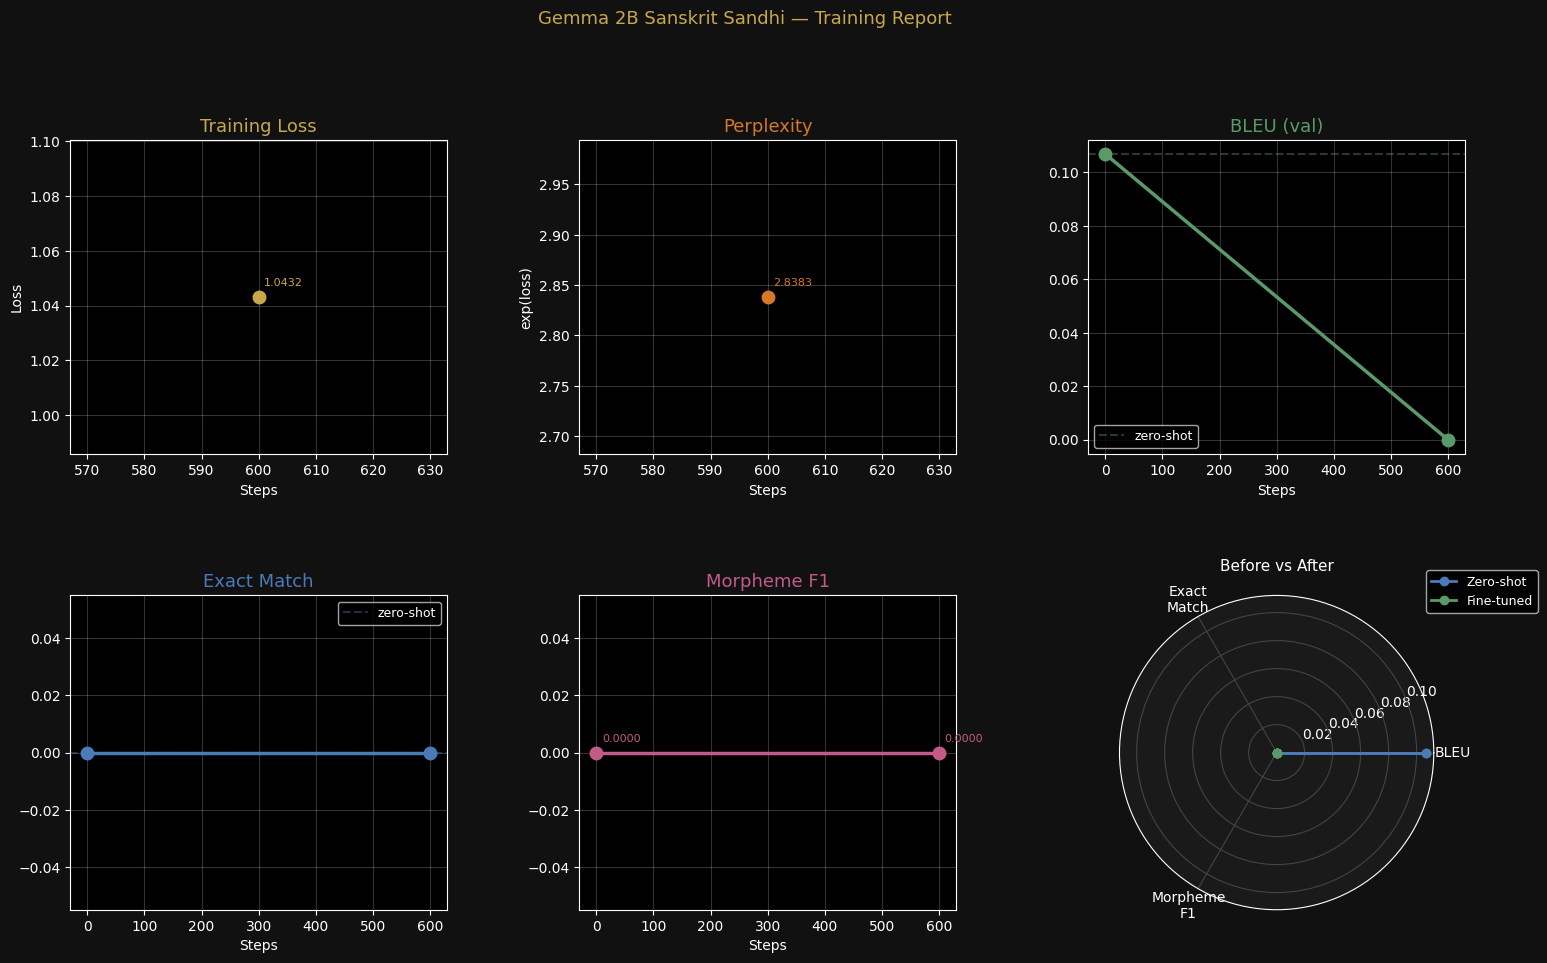

Saved -> /kaggle/working/sandhi_runs/gemma_sandhi/training_report.png


In [13]:
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec, numpy as np
plt.style.use('dark_background')
GOLD,AMBER,GREEN,BLUE,PINK='#c9a84c','#d4782a','#5a9a6a','#4a7ab8','#c45a8a'

res     = pd.read_csv(f'{ft_dir}/training_results.csv')
trained = res[res['round']>0]

fig = plt.figure(figsize=(18,10))
gs  = gridspec.GridSpec(2,3,figure=fig,hspace=0.45,wspace=0.35)

def p(ax,x,y,c,title,yl=''):
    ax.plot(x,y,'o-',color=c,lw=2.5,ms=9)
    for xi,yi in zip(x,y): ax.annotate(f'{yi:.4f}',(xi,yi),xytext=(4,8),
        textcoords='offset points',color=c,fontsize=8)
    ax.set_title(title,color=c,fontsize=13); ax.set_xlabel('Steps')
    ax.set_ylabel(yl); ax.grid(True,alpha=0.2)

p(fig.add_subplot(gs[0,0]),trained['steps'],trained['loss'],      GOLD, 'Training Loss','Loss')
p(fig.add_subplot(gs[0,1]),trained['steps'],trained['perplexity'],AMBER,'Perplexity','exp(loss)')

ax3=fig.add_subplot(gs[0,2])
ax3.plot(res['steps'],res['bleu'],'o-',color=GREEN,lw=2.5,ms=9)
ax3.axhline(res.iloc[0]['bleu'],ls='--',color=GREEN,alpha=0.4,label='zero-shot')
ax3.set_title('BLEU (val)',color=GREEN,fontsize=13); ax3.set_xlabel('Steps')
ax3.grid(True,alpha=0.2); ax3.legend(fontsize=9)

ax4=fig.add_subplot(gs[1,0])
ax4.plot(res['steps'],res['exact_match'],'o-',color=BLUE,lw=2.5,ms=9)
ax4.axhline(res.iloc[0]['exact_match'],ls='--',color=BLUE,alpha=0.4,label='zero-shot')
ax4.set_title('Exact Match',color=BLUE,fontsize=13); ax4.set_xlabel('Steps')
ax4.grid(True,alpha=0.2); ax4.legend(fontsize=9)

p(fig.add_subplot(gs[1,1]),res['steps'],res['token_f1'],PINK,'Morpheme F1')

ax6=fig.add_subplot(gs[1,2],polar=True)
lbs=['BLEU','Exact\nMatch','Morpheme\nF1']
bv=[res.iloc[0]['bleu'],res.iloc[0]['exact_match'],res.iloc[0]['token_f1']]
fv=[res.iloc[-1]['bleu'],res.iloc[-1]['exact_match'],res.iloc[-1]['token_f1']]
N=len(lbs); ang=[n/N*2*np.pi for n in range(N)]; ang+=ang[:1]
bv+=bv[:1]; fv+=fv[:1]
ax6.set_xticks(ang[:-1]); ax6.set_xticklabels(lbs,size=10,color='white')
ax6.plot(ang,bv,'o-',color=BLUE, lw=2,label='Zero-shot'); ax6.fill(ang,bv,alpha=0.1,color=BLUE)
ax6.plot(ang,fv,'o-',color=GREEN,lw=2,label='Fine-tuned'); ax6.fill(ang,fv,alpha=0.1,color=GREEN)
ax6.set_title('Before vs After',color='white',pad=18,fontsize=11)
ax6.legend(loc='upper right',bbox_to_anchor=(1.35,1.1),fontsize=9)
ax6.set_facecolor('#1a1a1a'); ax6.grid(color='#444')

fig.patch.set_facecolor('#111')
plt.suptitle('Gemma 2B Sanskrit Sandhi — Training Report',color=GOLD,fontsize=13,y=1.01)
plt.savefig(f'{ft_dir}/training_report.png',dpi=150,bbox_inches='tight',facecolor='#111')
plt.show(); print(f'Saved -> {ft_dir}/training_report.png')

## Cell 9 — Inference

In [14]:
def split_sandhi(text, temperature=0.0):
    inputs = tokenizer(make_inference_prompt(text), return_tensors='pt',
                       truncation=True, max_length=MAX_SEQ_LEN).to(DEVICE)
    model.eval()
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=GEN_MAX_NEW,
            do_sample=temperature>0, temperature=max(temperature,1e-6),
            pad_token_id=tokenizer.eos_token_id,
        )
    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    return decoded.split('Output:')[-1].strip().split('\n')[0].strip()

test_sample = df_val_short.sample(min(15, len(df_val_short)), random_state=77)
correct = 0
print(f'{"─"*80}')
for _, row in test_sample.iterrows():
    pred  = split_sandhi(row['sandhi_input'])
    ref   = row['split_output']
    match = pred.strip() == ref.strip()
    if match: correct += 1
    mark = 'OK' if match else 'X '
    print(f'[{mark}] IN : {row["sandhi_input"][:65]}')
    print(f'      OUT: {pred[:70]}')
    if not match:
        print(f'      REF: {ref[:70]}')
    print()
print(f'{"─"*80}')
print(f'Accuracy: {correct}/{len(test_sample)} = {correct/len(test_sample)*100:.0f}%')

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


────────────────────────────────────────────────────────────────────────────────
[X ] IN : संप्रति साग्निस्वेदानां सङ्करादीनां लक्षणमभिधातुं सङ्करादीन् स्वे
      OUT: user
      REF: संप्रति साग्निस्वेदानां सङ्करादीनां लक्षणम्+अभिधातुं सङ्करादीन् स्वेदा

[X ] IN : ) कथं कुर्वन्तीत्याह---तस्मिंस्तस्मिन्नित्यादि| तां तां युक्तिमास
      OUT: 
      REF: ) कथं कुर्वन्ति+इति+आह---तस्मिन्+तस्मिन्+इत्यादि| तां तां युक्तिम्+आसा

[X ] IN : रोगाश्चोत्सेधसामान्यदधिमांसार्बुदादयः|विशिष्टा नामरूपाभ्यां निर्द
      OUT: 
      REF: रोगाः+च+उत्सेधसामान्यदधिमांसाः+बुदादयः|विशिष्टा नामरूपाभ्यां निर्देश्य

[X ] IN : गुणत्रयविभेदेन मूर्तित्रयमुपेयुषे|त्रयीभुवे त्रिनेत्राय त्रिलोकीप
      OUT: 
      REF: गुणत्रयविभेदेन मूर्तित्रयम्+उपेयुषे त्रयीभुवे त्रिनेत्रायत्रिलोकीपतये 

[X ] IN : साङ्कृत्यो बैजवापिश्च कुशिको बादरायणः|बडिशः शरलोमा च काप्यकात्याय
      OUT: 
      REF: साङ्कृत्यः+ वैजवापिः+चकुशिकः+ बादरायणःबडिशः शरलोमा च काप्यकात्यायनौ+उभ

[X ] IN : येषांम मध्यबला रोगाः कफपित्तसमुत्थिताः|वम्यतीसारहृ

## Cell 10 — Error analysis

In [15]:
n_analyse  = min(200, len(df_val_short))
analyse_df = df_val_short.sample(n_analyse, random_state=7)
errors, correct_preds = [], []
model.eval()

print(f'Analysing {n_analyse} val examples...')
for idx,(_, row) in enumerate(analyse_df.iterrows()):
    if idx % 50 == 0: print(f'  {idx}/{n_analyse}')
    pred  = split_sandhi(row['sandhi_input'])
    ref   = row['split_output']
    right = pred.strip() == ref.strip()
    ref_m  = set(m.strip() for m in ref.split(SEPARATOR) if m.strip())
    pred_m = set(m.strip() for m in pred.split(SEPARATOR) if m.strip())
    jac    = len(ref_m & pred_m)/len(ref_m | pred_m) if (ref_m or pred_m) else 0.0
    entry  = {'input':row['sandhi_input'],'expected':ref,'predicted':pred,
               'exact_match':right,'morpheme_f1':round(jac,3),
               'n_junctions_ref':len(ref_m)-1,'n_junctions_pred':len(pred_m)-1}
    (correct_preds if right else errors).append(entry)

avg_f1 = sum(e['morpheme_f1'] for e in errors+correct_preds)/n_analyse
print(f'Exact match     : {len(correct_preds)}/{n_analyse} = {len(correct_preds)/n_analyse*100:.1f}%')
print(f'Avg morpheme F1 : {avg_f1:.3f}')

if errors:
    print(f'\nWorst errors (lowest morpheme F1):')
    for e in sorted(errors, key=lambda x: x['morpheme_f1'])[:5]:
        print(f"  IN : {e['input'][:70]}")
        print(f"  EXP: {e['expected'][:70]}")
        print(f"  GOT: {e['predicted'][:70]}")
        print(f"  F1={e['morpheme_f1']}  junctions: ref={e['n_junctions_ref']} pred={e['n_junctions_pred']}")
        print()

pd.DataFrame(errors).to_csv(       f'{ft_dir}/error_log.csv',  index=False,encoding='utf-8')
pd.DataFrame(correct_preds).to_csv(f'{ft_dir}/correct_log.csv',index=False,encoding='utf-8')
print(f'Error log   -> {ft_dir}/error_log.csv   ({len(errors)} rows)')
print(f'Correct log -> {ft_dir}/correct_log.csv ({len(correct_preds)} rows)')

Analysing 172 val examples...
  0/172
  50/172
  100/172
  150/172
Exact match     : 0/172 = 0.0%
Avg morpheme F1 : 0.000

Worst errors (lowest morpheme F1):
  IN : स त्रातारमनासाद्य बालस्त्यजति जीवितम्|गोधा लाङ्गूलबद्धेवाकृष्यमाणा बली
  EXP: स त्रातारम्+अनासाद्य बालः+त्यजति जीवितम्|गोधा लाङ्गूलबद्धा+इव+आकृष्यमा
  GOT: 
  F1=0.0  junctions: ref=4 pred=-1

  IN : | 19-23 | |
  EXP: | 19-23 | |
  GOT: 
  F1=0.0  junctions: ref=0 pred=-1

  IN : तत्र यद्रसतो मधुरं तद्वीर्यतः शीतमिति वक्तव्ये यद्रसपाकयोरिति करोति, त
  EXP: तत्र यद्रसतः+ मधुरं तद्वीर्यतः शीतम्+इति वक्तव्ये यद्रसपाकयोः+इति करोत
  GOT: user
  F1=0.0  junctions: ref=6 pred=0

  IN : शीताः पीनसकर्त्र्यश्च मधुरा गुर्व्य एव च|चतुर्थः शाकवर्गोऽयं पत्रकन्दफ
  EXP: शीताः पीनसकर्त्र्यः+च मधुराः+ गुर्व्यः+ एव च|चतुर्थः शाकवर्गः+अयं पत्र
  GOT: 
  F1=0.0  junctions: ref=4 pred=-1

  IN : स्वेदाभ्यङ्गावगाहाश्च वर्तयो बस्तिकर्म च|हितं प्रतिहते वर्चस्यन्नपानं 
  EXP: स्वेदाभ्यङ्गावगाहाः+च वर्तयः+ बस्तिकर्म च|हितं प्रति-हते वर्चस्यन्नपान
 

## Cell 11 — Output listing

In [16]:
for root,dirs,files in os.walk(OUTPUT_DIR):
    d=root.replace(OUTPUT_DIR,'').count(os.sep)
    print('  '*d+'+-'+os.path.basename(root)+'/')
    for fn in sorted(files):
        sz=os.path.getsize(os.path.join(root,fn))
        print(f"{'  '*(d+1)}  {fn:45s}  {sz/(1e6 if sz>1e6 else 1e3):.1f} {'MB' if sz>1e6 else 'KB'}")
print('\nDownload from the Kaggle Output tab.')
print('  gemma_sandhi/final_lora_adapter/  <- LoRA weights')
print('  gemma_sandhi/training_results.csv <- BLEU / exact-match')
print('  gemma_sandhi/error_log.csv        <- incorrect predictions')

+-sandhi_runs/
  +-data_splits/
      train.csv                                      2.3 MB
      val.csv                                        406.5 KB
  +-gemma_sandhi/
      correct_log.csv                                0.0 KB
      error_log.csv                                  106.4 KB
      training_report.png                            207.3 KB
      training_results.csv                           0.1 KB
    +-round_1/
        README.md                                      1.4 KB
      +-checkpoint-600/
          README.md                                      5.2 KB
          adapter_config.json                            1.0 KB
          adapter_model.safetensors                      39.3 MB
          chat_template.jinja                            0.6 KB
          optimizer.pt                                   78.7 MB
          rng_state.pth                                  14.6 KB
          scheduler.pt                                   1.5 KB
          tokenizer.json        

In [ ]:
err = pd.read_csv(f"{ft_dir}/error_log.csv")

plt.figure(figsize=(10,5))
plt.hist(err["morpheme_f1"], bins=20)
plt.title("Distribution of Morpheme F1 on Errors")
plt.xlabel("F1 score")
plt.ylabel("Count")
plt.show()